# День 5 — Error analysis

**Цель:** понять, где именно ошибается лучшая модель.

Скриптовый аналог: [`error_analysis.py`](../error_analysis.py).

In [1]:
import sys, os
# Добавляем корень проекта в путь, чтобы импортировать модули (config, preprocess, ...)
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from config import REPORTS_DIR, MODELS_DIR, ID2LABEL
from preprocess import load_and_preprocess
from train_improved import WordCharVectorizer  # нужно для загрузки векторайзера
%matplotlib inline

In [3]:
df = load_and_preprocess()
test_idx = json.loads((REPORTS_DIR / 'split_indices.json').read_text())['test']
model = joblib.load(MODELS_DIR / 'best_model.pkl')
vec = joblib.load(MODELS_DIR / 'best_vectorizer.pkl')

test_df = df.loc[test_idx].copy()
test_df['pred'] = model.predict(vec.transform(test_df['text_clean']))
labels = sorted(ID2LABEL); names = [ID2LABEL[i] for i in labels]
print(classification_report(test_df['label'], test_df['pred'], target_names=names, digits=4))

              precision    recall  f1-score   support

    negative     0.5283    0.4746    0.5000       118
     neutral     0.8167    0.8507    0.8333       576
    positive     0.7744    0.7493    0.7616       371

    accuracy                         0.7737      1065
   macro avg     0.7064    0.6915    0.6983      1065
weighted avg     0.7700    0.7737    0.7714      1065



## Confusion matrix

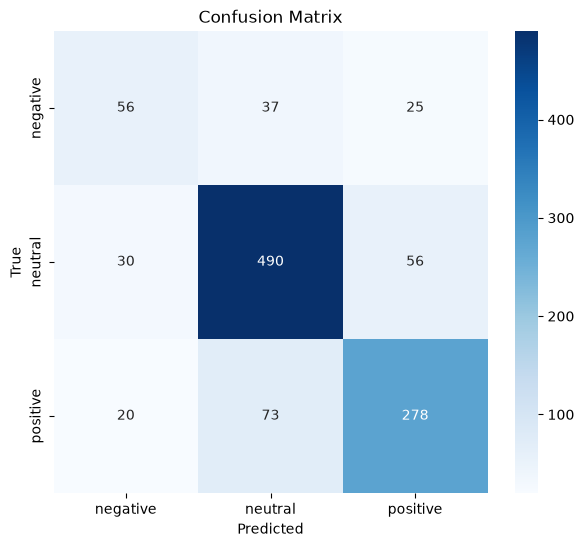

In [4]:
cm = confusion_matrix(test_df['label'], test_df['pred'], labels=labels)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
plt.ylabel('True'); plt.xlabel('Predicted'); plt.title('Confusion Matrix'); plt.show()

## Частые типы ошибок и примеры

In [5]:
from collections import Counter
errors = test_df[test_df['label'] != test_df['pred']]
pairs = Counter((ID2LABEL[t], ID2LABEL[p]) for t, p in zip(errors['label'], errors['pred']))
for (t, p), c in pairs.most_common():
    print(f'{t} -> {p}: {c}')

positive -> neutral: 73
neutral -> positive: 56
negative -> neutral: 37
neutral -> negative: 30
negative -> positive: 25
positive -> negative: 20


In [6]:
L2I = {v: k for k, v in ID2LABEL.items()}
for (t, p), _ in pairs.most_common(3):
    sub = errors[(errors['label'] == L2I[t]) & (errors['pred'] == L2I[p])]
    print(f'\n[{t} -> {p}]')
    for txt in sub['text'].head(2):
        print('  -', txt[:160])


[positive -> neutral]
  - The court found TelecomInvest 's arguments convincing .
  - Last year the company raised its turnover to approximately 7 million litas EUR 2 mln , from 6.1 million litas in 2004 .

[neutral -> positive]
  - Finnish Componenta has published its new long-term strategy for the period 2011-2015 with the aim of growing together with its customers .
  - Neste Shipping is the most likely to remain Finnish as the oil sector and its transports are significant for emergency supply .

[negative -> neutral]
  - Coca-Cola was the market leader of manufacturers with a market share of 36.9 % , down 2.2 % from the corresponding period in 2004-2005 .
  - Border Guard Service has banned the mooring of the company car-shipping ferry on its test travel at the railroad-car terminal of the Russian port as the border 


## Выводы
- Основная путаница — между `neutral` и `positive`.
- `negative` — самый редкий класс и самый низкий precision.
- Тяжелее всего длинные предложения с несколькими фактами разной тональности.
- Дальше: контекстные эмбеддинги (finBERT), больше данных класса `negative`.